Kacper Kaszuba
Dataset:
https://datadryad.org/dataset/doi:10.5061/dryad.bp26v20

### Opis:

Dataset
**PHYLACINE 1.2** — The Phylogenetic Atlas of Mammal Macroecology
- 5,831 known mammal species
- Two key files:
  - `Trait_data.csv` — body mass (`Mass.g`), diet, habitat type, taxonomic order, IUCN status (`IUCN.Status.1.2`)
  - `Spatial_metadata.csv` — geographic range size (`Number.Cells.Current.Range`, `Number.Cells.Present.Natural.Range`)
- Files are merged on `Binomial.1.2` (species name)

### Thesis
> **"Body mass and geographic range size are the dominant biological predictors of extinction risk in mammals, independent of taxonomic order."**

This thesis is confronted using **Random Forest feature importance** — if `Log.Mass` and `Log.Range.Current` rank highest, thesis is confirmed. If `Order.Encoded` (taxonomic order) ranks high, it suggests taxonomy matters more than claimed.

In [3]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML — preprocessing & classical models
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight

# Neural Network
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Optional but useful
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

Wczytanie Dataset

In [4]:
trait = pd.read_csv('Trait_data.csv')
spatial = pd.read_csv('Spatial_metadata.csv')

In [5]:
display(trait.shape)
display(spatial.shape)

(5831, 24)

(5831, 12)

In [6]:
trait_set   =  set(trait['Binomial.1.2'])
spatial_set   =  set(spatial['Binomial.1.2'])

if trait_set == spatial_set:
  print("tak są rowne")
else:
  print("nie sa rozne")

tak są rowne


In [7]:
print(f"dlogosc trait:  {len(trait_set)}")
print(f"dlogosc spatial:  {len(spatial_set)}")

dlogosc trait:  5831
dlogosc spatial:  5831


Po  tym sprawdzeniyu wiemy ze ze gatunki w obu tabelach są takie same a więc mozemy je połaczyć

In [8]:
trait.head(5)

,Binomial.1.2,Order.1.2,Family.1.2,Genus.1.2,Species.1.2,Terrestrial,Marine,Freshwater,Aerial,Life.Habit.Method,...,Mass.Comparison,Mass.Comparison.Source,Island.Endemicity,IUCN.Status.1.2,Added.IUCN.Status.1.2,Diet.Plant,Diet.Vertebrate,Diet.Invertebrate,Diet.Method,Diet.Source
0,Abditomys_latidens,Rodentia,Muridae,Abditomys,latidens,1,0,0,0,Reported,...,NaN,NaN,Occurs only on isolated islands,DD,No,100,0,0,Reported 000 Species,"Wilman, H., et al. 2014. EltonTraits 1.0: spec..."
1,Abeomelomys_sevia,Rodentia,Muridae,Abeomelomys,sevia,1,0,0,0,Reported,...,NaN,NaN,Occurs on large land bridge islands,LC,No,78,3,19,Imputed 000 Species,PHYLACINE 1.2
2,Abrawayaomys_ruschii,Rodentia,Cricetidae,Abrawayaomys,ruschii,1,0,0,0,Reported,...,NaN,NaN,Occurs on mainland,LC,No,88,1,11,Imputed 000 Species,PHYLACINE 1.2
3,Abrocoma_bennettii,Rodentia,Abrocomidae,Abrocoma,bennettii,1,0,0,0,Reported,...,NaN,NaN,Occurs on mainland,LC,No,100,0,0,Reported 000 Species,"Wilman, H., et al. 2014. EltonTraits 1.0: spec..."
4,Abrocoma_boliviensis,Rodentia,Abrocomidae,Abrocoma,boliviensis,1,0,0,0,Reported,...,NaN,NaN,Occurs on mainland,CR,No,100,0,0,Reported 000 Species,"Wilman, H., et al. 2014. EltonTraits 1.0: spec..."


In [9]:
spatial.head(5)

,Binomial.1.2,Order.1.2,Family.1.2,Genus.1.2,Species.1.2,Certainty.Level,Modification,Motivation,Last.Manual.Present.Natural.Modification,Number.Cells.Current.Range,Number.Cells.Present.Natural.Range,Change.In.Cells
0,Abditomys_latidens,Rodentia,Muridae,Abditomys,latidens,3) Merger of likely human caused disjunct rang...,Connected via ecoregion.,Disjunct range likely anthropogenic in cause.,Version 1.0,5,9,4
1,Abeomelomys_sevia,Rodentia,Muridae,Abeomelomys,sevia,0) Present Natural range identical to IUCN range,NaN,NaN,NaN,10,10,0
2,Abrawayaomys_ruschii,Rodentia,Cricetidae,Abrawayaomys,ruschii,0) Present Natural range identical to IUCN range,NaN,NaN,NaN,20,20,0
3,Abrocoma_bennettii,Rodentia,Abrocomidae,Abrocoma,bennettii,0) Present Natural range identical to IUCN range,NaN,NaN,NaN,28,28,0
4,Abrocoma_boliviensis,Rodentia,Abrocomidae,Abrocoma,boliviensis,0) Present Natural range identical to IUCN range,NaN,NaN,NaN,1,1,0


In [10]:
spatial_to_merge  =  spatial[["Binomial.1.2", 'Number.Cells.Current.Range', 'Number.Cells.Present.Natural.Range']]

In [11]:
trait_merged =  pd.merge(trait, spatial_to_merge, how='left',  on='Binomial.1.2')
trait_merged.head(5)

,Binomial.1.2,Order.1.2,Family.1.2,Genus.1.2,Species.1.2,Terrestrial,Marine,Freshwater,Aerial,Life.Habit.Method,...,Island.Endemicity,IUCN.Status.1.2,Added.IUCN.Status.1.2,Diet.Plant,Diet.Vertebrate,Diet.Invertebrate,Diet.Method,Diet.Source,Number.Cells.Current.Range,Number.Cells.Present.Natural.Range
0,Abditomys_latidens,Rodentia,Muridae,Abditomys,latidens,1,0,0,0,Reported,...,Occurs only on isolated islands,DD,No,100,0,0,Reported 000 Species,"Wilman, H., et al. 2014. EltonTraits 1.0: spec...",5,9
1,Abeomelomys_sevia,Rodentia,Muridae,Abeomelomys,sevia,1,0,0,0,Reported,...,Occurs on large land bridge islands,LC,No,78,3,19,Imputed 000 Species,PHYLACINE 1.2,10,10
2,Abrawayaomys_ruschii,Rodentia,Cricetidae,Abrawayaomys,ruschii,1,0,0,0,Reported,...,Occurs on mainland,LC,No,88,1,11,Imputed 000 Species,PHYLACINE 1.2,20,20
3,Abrocoma_bennettii,Rodentia,Abrocomidae,Abrocoma,bennettii,1,0,0,0,Reported,...,Occurs on mainland,LC,No,100,0,0,Reported 000 Species,"Wilman, H., et al. 2014. EltonTraits 1.0: spec...",28,28
4,Abrocoma_boliviensis,Rodentia,Abrocomidae,Abrocoma,boliviensis,1,0,0,0,Reported,...,Occurs on mainland,CR,No,100,0,0,Reported 000 Species,"Wilman, H., et al. 2014. EltonTraits 1.0: spec...",1,1


In [12]:
display(trait_merged.shape)
display(trait_merged.describe())
display(trait_merged.info())

(5831, 26)

,Terrestrial,Marine,Freshwater,Aerial,Mass.g,Diet.Plant,Diet.Vertebrate,Diet.Invertebrate,Number.Cells.Current.Range,Number.Cells.Present.Natural.Range
count,5831.000000,5831.000000,5831.000000,5831.000000,5.831000e+03,5831.000000,5831.000000,5831.000000,5831.000000,5831.000000
mean,0.784600,0.023152,0.026582,0.199280,1.570861e+05,56.461327,9.075973,34.462699,341.547076,379.215572
std,0.411135,0.150399,0.160872,0.399493,3.145802e+06,43.241440,20.641177,38.551807,1922.439625,1929.320214
min,0.000000,0.000000,0.000000,0.000000,1.600000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,2.100000e+01,0.000000,0.000000,0.000000,6.000000,11.000000
50%,1.000000,0.000000,0.000000,0.000000,8.440000e+01,80.000000,0.000000,20.000000,39.000000,52.000000
75%,1.000000,0.000000,0.000000,0.000000,9.924000e+02,100.000000,4.000000,70.000000,188.000000,226.500000
max,1.000000,1.000000,1.000000,1.000000,1.900000e+08,100.000000,100.000000,100.000000,37542.000000,37542.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5831 entries, 0 to 5830
Data columns (total 26 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Binomial.1.2                        5831 non-null   object 
 1   Order.1.2                           5831 non-null   object 
 2   Family.1.2                          5831 non-null   object 
 3   Genus.1.2                           5831 non-null   object 
 4   Species.1.2                         5831 non-null   object 
 5   Terrestrial                         5831 non-null   int64  
 6   Marine                              5831 non-null   int64  
 7   Freshwater                          5831 non-null   int64  
 8   Aerial                              5831 non-null   int64  
 9   Life.Habit.Method                   5831 non-null   object 
 10  Life.Habit.Source                   5831 non-null   object 
 11  Mass.g                              5831 no

None

Budowanie Binary target na kolumnie `IUCN.Status.1.2`

In [13]:
trait_merged['IUCN.Status.1.2'].drop_duplicates()

,IUCN.Status.1.2
0,DD
1,LC
4,CR
17,NT
18,VU
19,EN
45,EP
413,EX
1486,EW


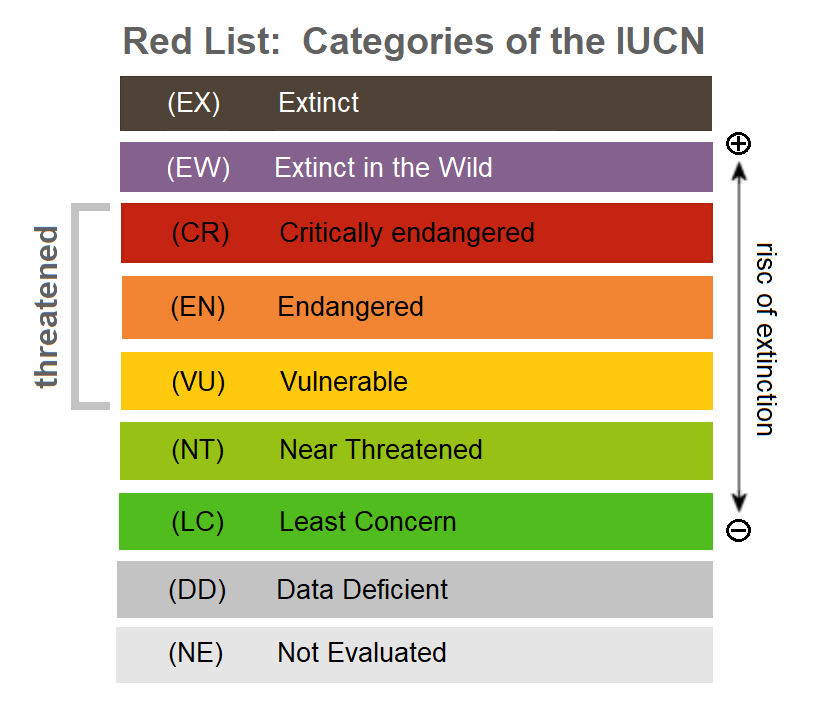

In [14]:
trait_merged['IUCN.Status.1.2'].value_counts()

,count
IUCN.Status.1.2,
LC,3157
DD,777
VU,525
EN,464
NT,350
EP,270
CR,204
EX,82
EW,2


**IUCN** Zgadza się z tabelą  z internetu

Autorzy dodali status `EP` Który oznacza wygineły  w  prechistorii

Aby nie  zaśmiecać wyników  ususniemy podane kolumny: `DD, EP, EX, EW`

Klasyfikacja Binarna:
- **0 — Not threatened:** LC (Least Concern), NT (Near Threatened)
- **1 — Threatened:** VU (Vulnerable), EN (Endangered), CR (Critically Endangered)

In [15]:
keep_categories =  ['LC',  'NT', 'VU', 'EN', 'CR']

#  Filtrowanie
trait_merged  = trait_merged[trait_merged['IUCN.Status.1.2'].isin(keep_categories)]
trait_merged.head()

,Binomial.1.2,Order.1.2,Family.1.2,Genus.1.2,Species.1.2,Terrestrial,Marine,Freshwater,Aerial,Life.Habit.Method,...,Island.Endemicity,IUCN.Status.1.2,Added.IUCN.Status.1.2,Diet.Plant,Diet.Vertebrate,Diet.Invertebrate,Diet.Method,Diet.Source,Number.Cells.Current.Range,Number.Cells.Present.Natural.Range
1,Abeomelomys_sevia,Rodentia,Muridae,Abeomelomys,sevia,1,0,0,0,Reported,...,Occurs on large land bridge islands,LC,No,78,3,19,Imputed 000 Species,PHYLACINE 1.2,10,10
2,Abrawayaomys_ruschii,Rodentia,Cricetidae,Abrawayaomys,ruschii,1,0,0,0,Reported,...,Occurs on mainland,LC,No,88,1,11,Imputed 000 Species,PHYLACINE 1.2,20,20
3,Abrocoma_bennettii,Rodentia,Abrocomidae,Abrocoma,bennettii,1,0,0,0,Reported,...,Occurs on mainland,LC,No,100,0,0,Reported 000 Species,"Wilman, H., et al. 2014. EltonTraits 1.0: spec...",28,28
4,Abrocoma_boliviensis,Rodentia,Abrocomidae,Abrocoma,boliviensis,1,0,0,0,Reported,...,Occurs on mainland,CR,No,100,0,0,Reported 000 Species,"Wilman, H., et al. 2014. EltonTraits 1.0: spec...",1,1
6,Abrocoma_cinerea,Rodentia,Abrocomidae,Abrocoma,cinerea,1,0,0,0,Reported,...,Occurs on mainland,LC,No,100,0,0,Reported 000 Species,"Wilman, H., et al. 2014. EltonTraits 1.0: spec...",82,82


In [16]:
trait_merged['IUCN.Status.1.2'].value_counts()

,count
IUCN.Status.1.2,
LC,3157
VU,525
EN,464
NT,350
CR,204


In [17]:
trait_merged.shape[0]

4700

wynik zgadza się z `3157+350+525+464+204 = 4700`

In [18]:
# Tworzymy kolumne Threatened (0/1)
trait_merged["Threatened"] = trait_merged['IUCN.Status.1.2'].isin(['VU', 'EN', 'CR']).astype(int)
trait_merged["Threatened"]

,Threatened
1,0
2,0
3,0
4,1
6,0
...,...
5826,0
5827,1
5828,1
5829,1


In [19]:
trait_merged["Threatened"].value_counts()

,count
Threatened,
0,3507
1,1193


In [20]:
display(trait_merged["Mass.g"].min())
display(trait_merged["Number.Cells.Current.Range"].min())
display(trait_merged["Number.Cells.Present.Natural.Range"].min())


1.6

0

0

Jak widać wartości dla `Number.Cells.Current.Range` i `Number.Cells.Present.Natural.Range` mogą być  `0`, dlatego w następnym kroku uzyjemy `log1p`, bo gdy wystapi `0` nie wyrzuci on błędu oraz dla małych wartości działa lepiej niż `log`

Następnie kolumne `Mass.g` musimy zlogarytmizować aby usunąc  rozstrzxał wagowy. Gdybyśmy  pomineli ten  krok to małe ssaki których jest  znaczna część w zbiorze zostały by zdominowany przez przypadki z duzą wagą.  Logarytm rozwiązuje ten problem bo "ściska" duże wagi  i "rozciąga" małe

In [21]:
# Tworzymy 3 nowe kolumny Log.Mass, Log.Range.Current, Log.Range.Natural
trait_merged["Log.Mass"] = np.log1p(trait_merged["Mass.g"])
trait_merged["Log.Range.Current"] = np.log1p(trait_merged["Number.Cells.Current.Range"])
trait_merged["Log.Range.Natural"] = np.log1p(trait_merged["Number.Cells.Present.Natural.Range"])

In [22]:
display(trait_merged["Log.Mass"])
display(trait_merged["Log.Range.Current"])
display(trait_merged["Log.Range.Natural"])

,Log.Mass
1,3.970292
2,4.158883
3,5.525453
4,5.068904
6,5.525453
...,...
5826,3.610918
5827,4.553877
5828,4.820282
5829,4.615121


,Log.Range.Current
1,2.397895
2,3.044522
3,3.367296
4,0.693147
6,4.418841
...,...
5826,5.365976
5827,2.564949
5828,1.386294
5829,1.386294


,Log.Range.Natural
1,2.397895
2,3.044522
3,3.367296
4,0.693147
6,4.418841
...,...
5826,5.365976
5827,2.564949
5828,1.386294
5829,3.496508


Sprawdzamy  różnice

In [23]:
display(trait_merged["Log.Mass"].describe())
display(trait_merged["Mass.g"].describe())

,Log.Mass
count,4700.000000
mean,5.121728
std,2.726751
min,0.955511
25%,3.072693
50%,4.359909
75%,6.708236
max,19.062535


,Mass.g
count,4.700000e+03
mean,1.284192e+05
std,3.421710e+06
min,1.600000e+00
25%,2.060000e+01
50%,7.725000e+01
75%,8.181250e+02
max,1.900000e+08


In [24]:
display(trait_merged["Log.Range.Current"].describe())
display(trait_merged["Number.Cells.Current.Range"].describe())

,Log.Range.Current
count,4700.000000
mean,4.092058
std,1.859333
min,0.000000
25%,2.708050
50%,4.127134
75%,5.472271
max,10.514014


,Number.Cells.Current.Range
count,4700.000000
mean,331.738511
std,1706.740123
min,0.000000
25%,14.000000
50%,61.000000
75%,237.000000
max,36827.000000


In [25]:
display(trait_merged["Log.Range.Natural"].describe())
display(trait_merged["Number.Cells.Present.Natural.Range"].describe())

,Log.Range.Natural
count,4700.000000
mean,4.189782
std,1.822820
min,0.000000
25%,2.833213
50%,4.189655
75%,5.529429
max,10.514014


,Number.Cells.Present.Natural.Range
count,4700.000000
mean,347.898085
std,1709.874818
min,0.000000
25%,16.000000
50%,65.000000
75%,251.000000
max,36827.000000


Jak widać operacja `log1p` się udała, na podstawie `Mass.g` i `Log.Mass` można zauważyć że w przypadku  `Mass.g` `mean ≈ 128 419`, ale `std ≈ 3 421 710` std jest 27 razy większe niż mean. To jest dokładnie to o czym pisałem wyżej przykładowy wieloryb znacznie zabóża skale. Natomiast dla `Log.Mass` `mean ≈ 5.12`, `std ≈ 2.73` w tym przypadku std jest mniejsze niż mean, rozkład wygląda znacznie lepiej niż wcześniej.
Można też zauważyć ze w `Mass.g` `75%` to 818g a `max` wynosi 190 000 000g. Po log `75% = 6.7`, `max = 19.06`.

In [26]:
trait_merged['Order.1.2'].value_counts()

,count
Order.1.2,
Rodentia,1862
Chiroptera,952
Primates,417
Eulipotyphla,373
Carnivora,283
Cetartiodactyla,260
Diprotodontia,139
Lagomorpha,87
Didelphimorphia,81


In [27]:
le = LabelEncoder()
trait_merged["Order.Encoded"] = le.fit_transform(trait_merged['Order.1.2'])
display(trait_merged["Order.Encoded"])
print(f"Category Mapping: {le.classes_}")

,Order.Encoded
1,23
2,23
3,23
4,23
6,23
...,...
5826,23
5827,23
5828,23
5829,23


Category Mapping: ['Afrosoricida' 'Carnivora' 'Cetartiodactyla' 'Chiroptera' 'Cingulata'
 'Dasyuromorphia' 'Dermoptera' 'Didelphimorphia' 'Diprotodontia'
 'Eulipotyphla' 'Hyracoidea' 'Lagomorpha' 'Macroscelidea' 'Microbiotheria'
 'Monotremata' 'Notoryctemorphia' 'Paucituberculata' 'Peramelemorphia'
 'Perissodactyla' 'Pholidota' 'Pilosa' 'Primates' 'Proboscidea' 'Rodentia'
 'Scandentia' 'Sirenia' 'Tubulidentata']


In [28]:
display(trait_merged["Order.Encoded"].value_counts())

,count
Order.Encoded,
23,1862
3,952
21,417
9,373
1,283
2,260
8,139
11,87
7,81


In [29]:
data_to_check = trait_merged[['Log.Mass', 'Log.Range.Current', 'Log.Range.Natural', 'Order.Encoded', 'Terrestrial', 'Marine', 'Freshwater', 'Aerial', 'Diet.Plant', 'Diet.Vertebrate', 'Diet.Invertebrate']]

data_to_check.isna().sum()

,0
Log.Mass,0
Log.Range.Current,0
Log.Range.Natural,0
Order.Encoded,0
Terrestrial,0
Marine,0
Freshwater,0
Aerial,0
Diet.Plant,0
Diet.Vertebrate,0


In [30]:
trait_merged['Mass.Method'].value_counts()

,count
Mass.Method,
Reported,4127
Assumed isometric based on head-body length,237
Assumed isometric based on forearm length,126
Imputed,112
Assumed isometric based on skull size,59
Assumed isometric based on mandible size,17
As relative of suggested similar size,12
Assumed isometric based on centroid size,3
Assumed isometric based on bone size,2


## Wykresy przed trenowaniem modeli

### 1.  Wykres słupkowy rozkładu kategorii IUCN

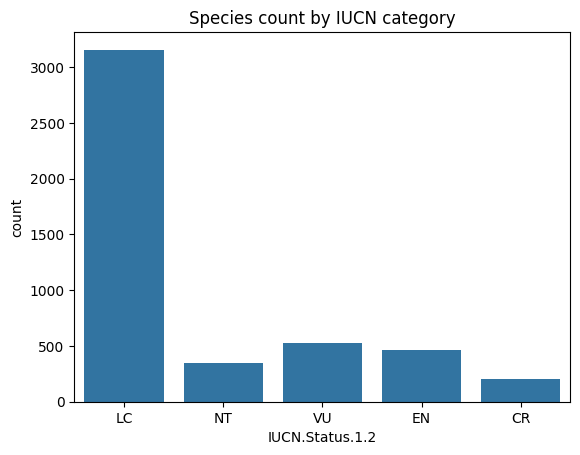

In [31]:
sns.countplot(x='IUCN.Status.1.2', data=trait_merged, order=['LC','NT','VU','EN','CR'])
plt.title('Species count by IUCN category')
plt.savefig('class_distribution.png', dpi=150)
plt.show()

### 2. Boxplot: `Log.Mass` vs `Threatened`

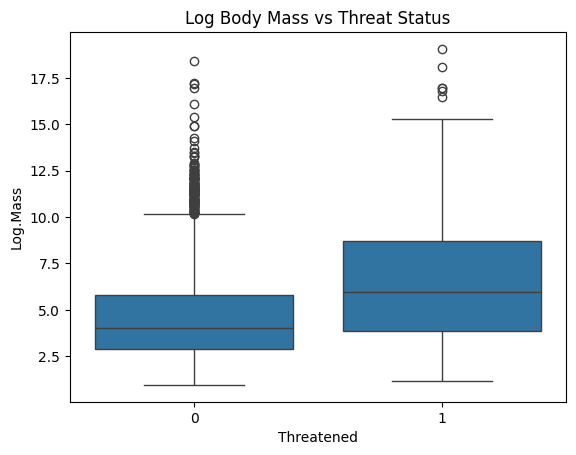

In [32]:
sns.boxplot(x='Threatened', y='Log.Mass',  data=trait_merged)
plt.title('Log Body Mass vs Threat Status')
plt.savefig('mass_vs_threat.png', dpi=150)
plt.show()

### 3. Boxplot: `Log.Range.Current` vs `Threatened`

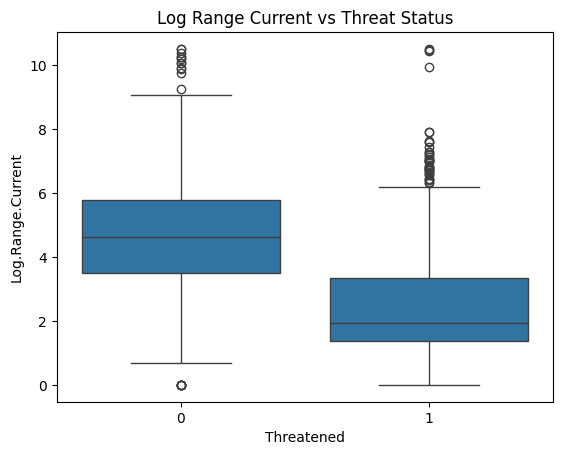

In [33]:
sns.boxplot(x='Threatened', y='Log.Range.Current',  data=trait_merged)
plt.title('Log Range Current vs Threat Status')
plt.savefig('range_vs_threat.png', dpi=150)
plt.show()

###  4. Heatmapa korelacji

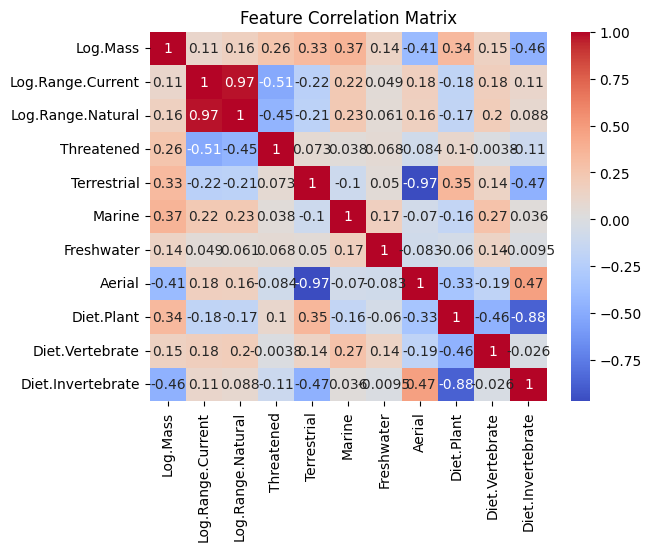

In [34]:
kor_cols = ['Log.Mass', 'Log.Range.Current', 'Log.Range.Natural', 'Threatened', 'Terrestrial', 'Marine', 'Freshwater', 'Aerial', 'Diet.Plant', 'Diet.Vertebrate', 'Diet.Invertebrate']
sns.heatmap(trait_merged[kor_cols].corr(),  annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

## Wstępne wnioski w oparciu o wykresy

1.  **Wykres 1 Species  count by IUCN category**

    Widać że przeważa grupa LC(Least Concern) następne 2 z podobnym wynikiem to  VU (Vulnerable) i EN (Edangered), najmniej natomiast jest CR (Critically Endangered)
    Widzimy tu też spory Class Imbalance proporcja 3:1, będzie miało to wpływ na wynik przewidywań modeli.

2. **Wykres 2 Log Body Mass vs Threat Status**

    Jak widać body  ma spore pokrycie z zagrożeniem jak i mediana  dla grupy 1 (zagrożone) jest wyższa niż dla grupy 0 (niezagrożone) może to sugerowac że większe ssaki są bardziej narażone na wyginięcie.

3. **Wykres 3 Log Range Current vs Threat Status**

    Tu jesteśmy  wstanie zaobserwować że boxy się nie pokrywają oraz mediana dla 1 (zagrozone gatunki) jest bardziej dolnej granicy co sugeruje mocne zależności między Range a Threat.

4. **Wykres 4 Feature Correlation Matrix**

    Jesteśmy w stanie zaobserwować kilka zależności
    - `Log.Range.Current` i `Log.Range.Natural` są bardzo podobne
    - `Log.Range.Current` i `Log.Range.Natural` mają silną korelacje z `Threatened`
    - `Log.Mass` ma słabszą korelacje z `Threatened`


## PCA

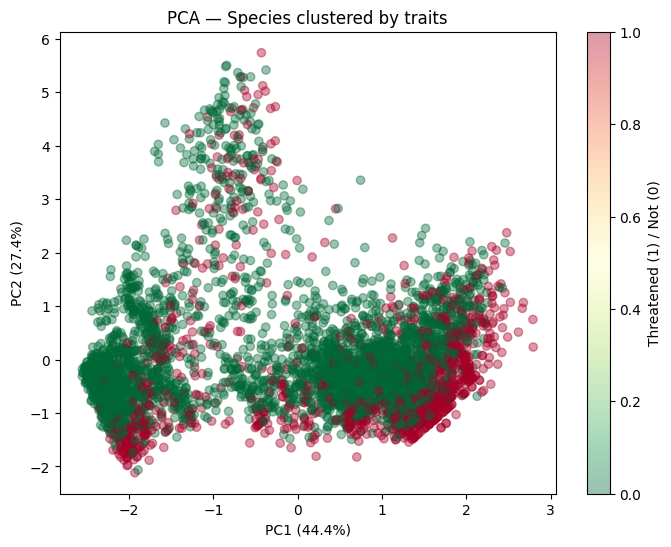

Variance explained: 71.7%


In [35]:
pca_features = ['Log.Mass', 'Log.Range.Current', 'Diet.Plant', 'Diet.Vertebrate', 'Diet.Invertebrate']
pca_df  = trait_merged[pca_features + ['Threatened']].dropna()

X_pca = StandardScaler().fit_transform(pca_df[pca_features])
pca= PCA(n_components=2)
components = pca.fit_transform(X_pca)

plt.figure(figsize=(8,6))
scatter = plt.scatter(components[:,0], components[:,1],
                      c=pca_df['Threatened'].values, cmap='RdYlGn_r', alpha=0.4)
plt.colorbar(scatter, label='Threatened (1) / Not (0)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA — Species clustered by traits')
plt.savefig('pca.png', dpi=150)
plt.show()

print(f'Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')


## Wnioski do PCA

1. Variance explained: 71.7% co jest dobrym wynikiem jak na to że patrzymy na 2D.
2. W prawym i lewym dolnym rogu widać skupiska (Threatened(1) i Not(0)). PC1 tłumaczy 44.4% cwariacji zawartej w orginalnych 5 cechach
3. Drugi kierunek PC2 tłumaczy 27.4% cech, jest to mniej bo PC1 wyłapał już dominujący kierunek zmienności.
4. Pierwsze dwie składowe tłumaczą wynik 71.7% wariacji, co oznacza że zamieniając z 5D do 2D tracimy około 30% wariacji.
5. Na wykresie widać częściową separacje czerwonych punktów od zieolonych co oznacza że cechy biologiczne niosą sygnał o zagrożeniu ale same go nie wyznaczają.
6. Możemy wywnioskować z tego to żę PCA daje nam wstępne założenie ze teza może być porpawna aczkolwiek należy to zweryfikowąć modleami ucznia maszynowego.

# Trenowanie modeli


## Logistic Regresion

In [36]:
model_features = ['Log.Mass', 'Log.Range.Current', 'Log.Range.Natural',
                  'Terrestrial', 'Marine', 'Freshwater', 'Aerial',
                  'Diet.Plant', 'Diet.Vertebrate', 'Diet.Invertebrate',
                  'Order.Encoded']

X = trait_merged[model_features]
y = trait_merged.loc[X.index, 'Threatened']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [37]:
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print(class_weight_dict)

{np.int64(0): np.float64(0.6699928724162509), np.int64(1): np.float64(1.970649895178197)}


In [38]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("--- Logistic Regresion ---")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]):.3f}")

--- Logistic Regresion ---
              precision    recall  f1-score   support

           0       0.94      0.87      0.90       701
           1       0.69      0.85      0.76       239

    accuracy                           0.86       940
   macro avg       0.81      0.86      0.83       940
weighted avg       0.88      0.86      0.87       940

ROC-AUC: 0.924


## Random Forest

In [39]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("--- Random Forest ---")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]):.3f}")

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       701
           1       0.78      0.62      0.69       239

    accuracy                           0.86       940
   macro avg       0.83      0.78      0.80       940
weighted avg       0.85      0.86      0.85       940

ROC-AUC: 0.916
